# **Imports**

In [36]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4f547e0126671e9f7fa57262efe82147732bad12b40df1efc5a7d3485dbd4466
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.combine import SMOTEENN
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# **EDA**

In [4]:
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [8]:
df['Diabetes_012'].value_counts(normalize=True)

,proportion
Diabetes_012,
0.0,0.842412
2.0,0.139333
1.0,0.018255


In [9]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['BMI'] < Q1 - 1.5*IQR) | (df['BMI'] > Q3 + 1.5*IQR)]
print("Number of BMI outliers:", len(outliers))

Number of BMI outliers: 9847


In [10]:
df.groupby('Diabetes_012')[['BMI','Age','PhysHlth','MentHlth']].mean()

,BMI,Age,PhysHlth,MentHlth
Diabetes_012,,,,
0.0,27.742521,7.786559,3.582416,2.944404
1.0,30.724466,9.083351,6.348305,4.529907
2.0,31.944011,9.379053,7.954479,4.461806


In [11]:
corr = df.corr()['Diabetes_012'].sort_values(ascending=False)
print(corr)

Diabetes_012            1.000000
GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Fruits                 -0.042192
HvyAlcoholConsump      -0.057882
Veggies                -0.058972
PhysActivity           -0.121947
Education              -0.130517
Income                 -0.171483
Name: Diabetes_012, dtype: float64


In [12]:
df[['BMI','Age','PhysHlth','MentHlth']].skew()

,0
BMI,2.122004
Age,-0.359903
PhysHlth,2.207395
MentHlth,2.721148


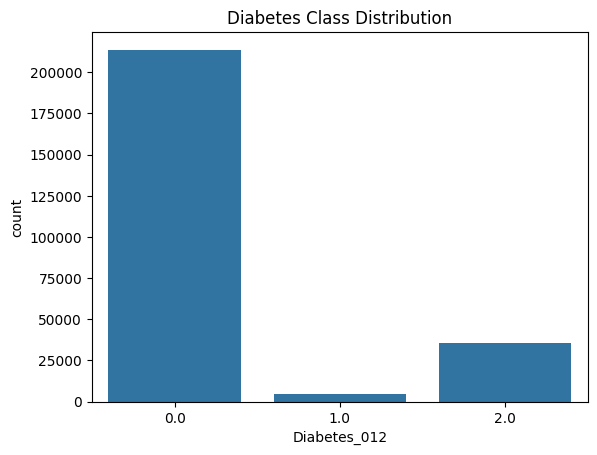

In [13]:
sns.countplot(x='Diabetes_012', data=df)
plt.title("Diabetes Class Distribution")
plt.show()

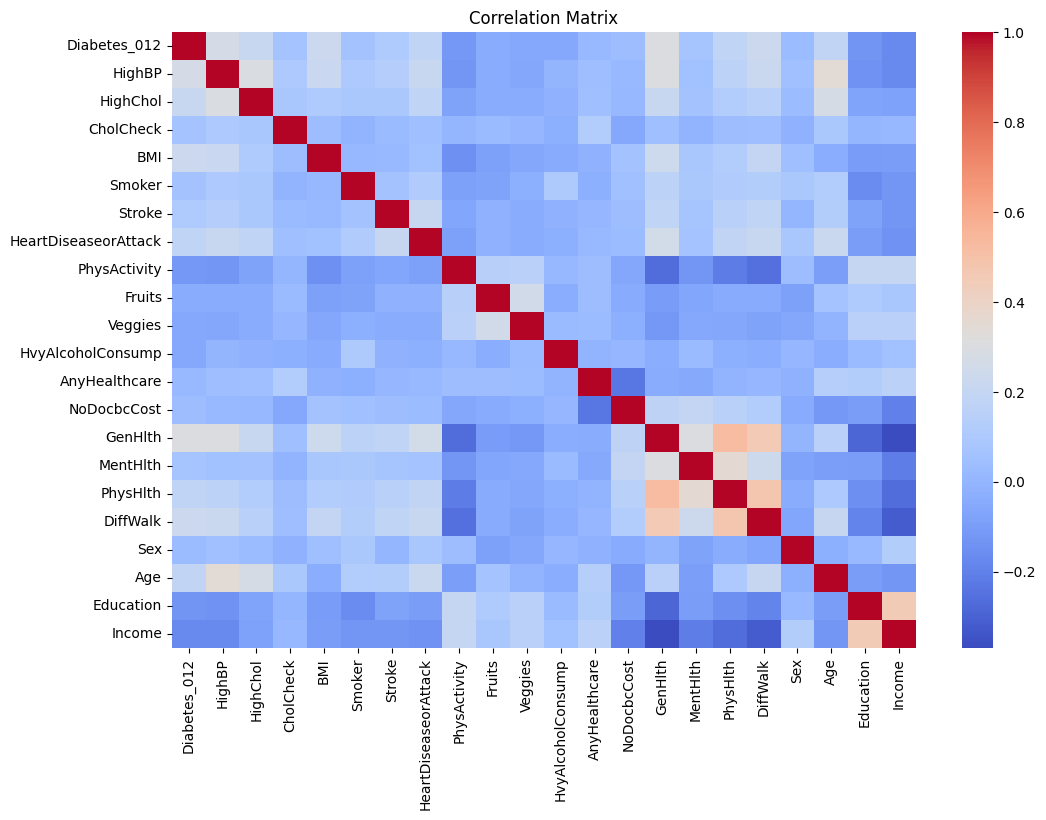

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

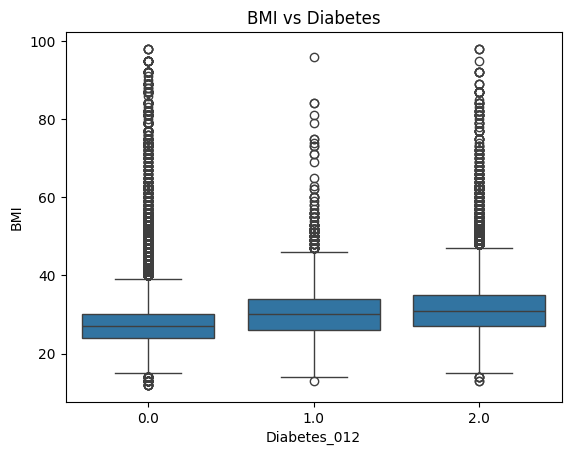

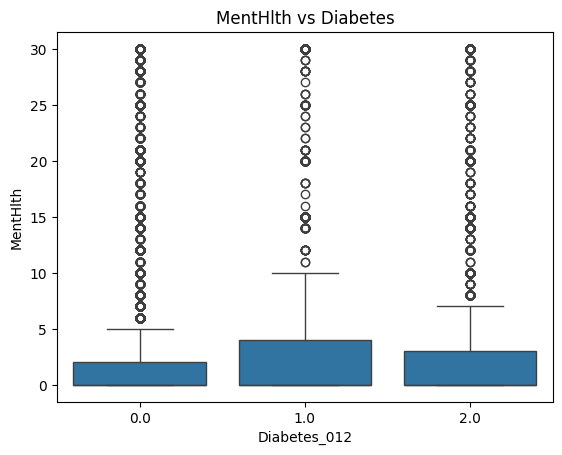

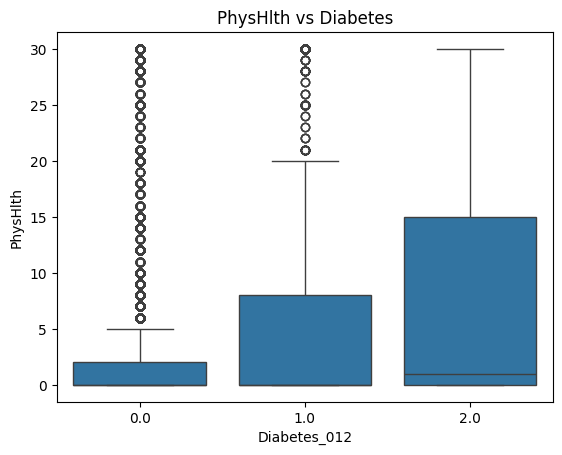

In [15]:
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth']

for col in continuous_cols:
    plt.figure()
    sns.boxplot(x='Diabetes_012', y=col, data=df)
    plt.title(f'{col} vs Diabetes')
    plt.show()

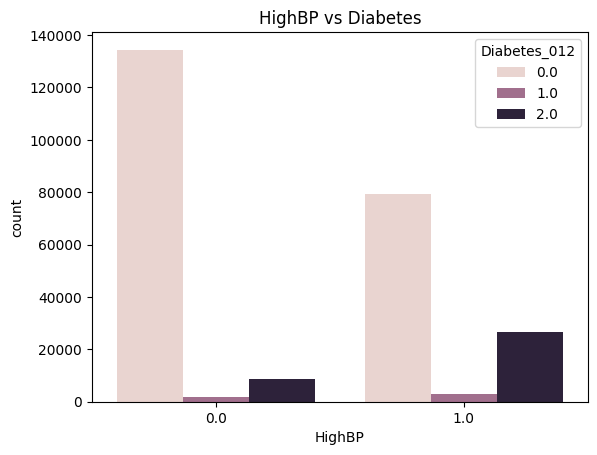

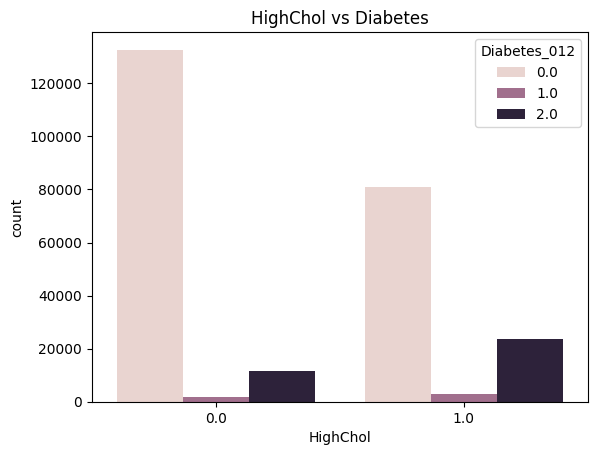

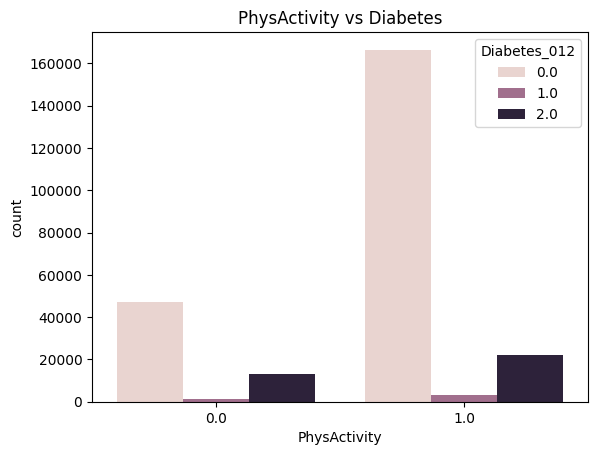

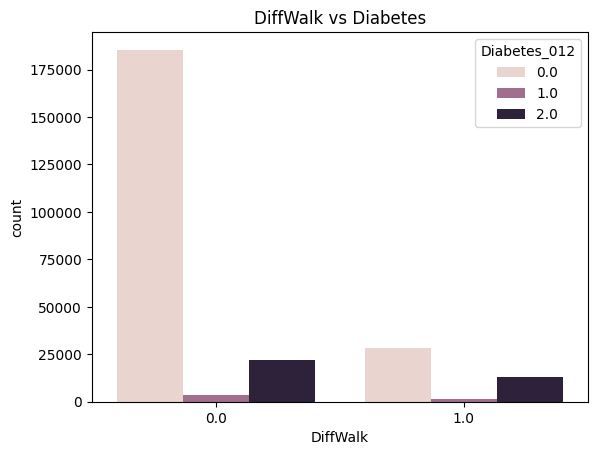

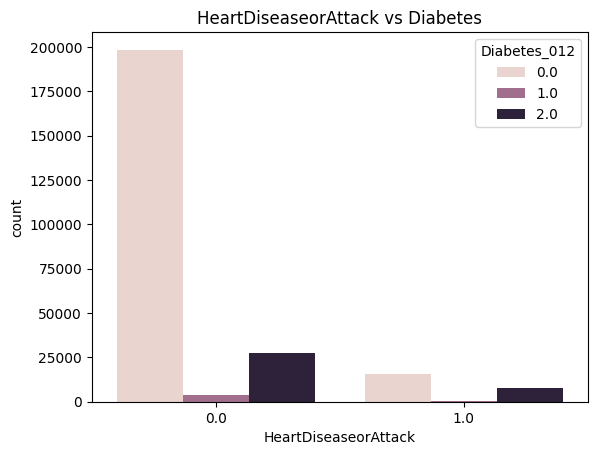

In [16]:
cat_cols = ['HighBP','HighChol','PhysActivity','DiffWalk','HeartDiseaseorAttack']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='Diabetes_012', data=df)
    plt.title(f'{col} vs Diabetes')
    plt.show()

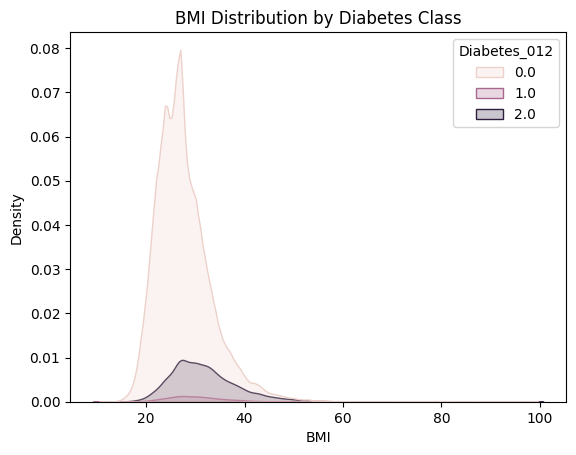

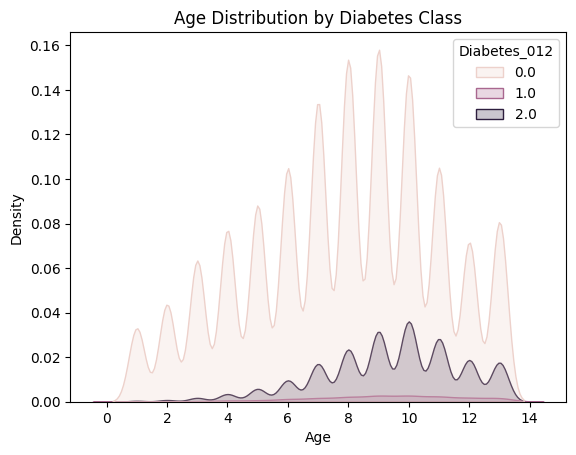

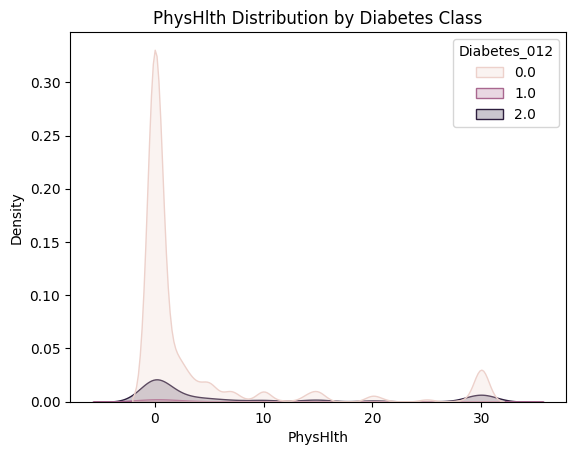

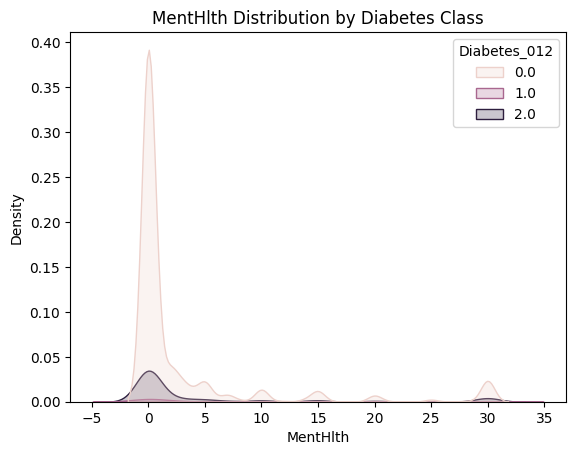

In [17]:
for col in ['BMI','Age','PhysHlth','MentHlth']:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue='Diabetes_012', fill=True)
    plt.title(f'{col} Distribution by Diabetes Class')
    plt.show()

# **Feature Engineering**

In [18]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 23899
Duplicates after: 0


In [19]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

drop_cols = ['AnyHealthcare', 'CholCheck', 'Sex']
X = X.drop(columns=drop_cols)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from imblearn.combine import SMOTEENN

sm = SMOTEENN(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [22]:
scaler = StandardScaler()

cols_to_scale = ['BMI', 'Age', 'MentHlth', 'PhysHlth']

X_train_res[cols_to_scale] = scaler.fit_transform(X_train_res[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [23]:
selector = SelectKBest(score_func=f_classif, k=10)

X_train_selected = selector.fit_transform(X_train_res, y_train_res)
X_test_selected = selector.transform(X_test)

selected_features = X_train_res.columns[selector.get_support()].tolist()

X_train_selected_df = pd.DataFrame(
    X_train_selected,
    columns=selected_features,
    index=X_train_res.index,
)
X_test_selected_df = pd.DataFrame(
    X_test_selected,
    columns=selected_features,
    index=X_test.index,
)

print("Selected features:", selected_features)

Selected features: ['HighBP', 'HighChol', 'BMI', 'HeartDiseaseorAttack', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']


In [24]:
print("Train shape:", X_train_selected_df.shape)
print("Test shape:", X_test_selected_df.shape)

Train shape: (365648, 10)
Test shape: (45957, 10)


# **Feature Selection**

In [28]:
X_train_model = X_train_selected_df.copy()
X_test_model = X_test_selected_df.copy()

In [29]:
print("Train shape:", X_train_model.shape)
print("Test shape:", X_test_model.shape)

Train shape: (365648, 10)
Test shape: (45957, 10)


In [30]:
X_train = X_train_model
X_test = X_test_model

In [31]:
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# svm_model = SVC(kernel='rbf', random_state=42)

# svm_model.fit(X_train, y_train_res)

# y_pred_svm = svm_model.predict(X_test)

In [32]:
# print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

In [ ]:



param_grid = {
    'n_neighbors': list(range(3, 32, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
)

grid.fit(X_train, y_train_res)
knn_final = grid.best_estimator_

y_pred_knn = knn_final.predict(X_test)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)
print("KNN test accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

# **SHAP**

In [ ]:
X_train_res_df = pd.DataFrame(X_train_res, columns=top_features)

In [ ]:
sample_X = X_train_res_df.sample(1000, random_state=42)

In [ ]:
explainer = shap.Explainer(knn_final.predict, sample_X)

In [ ]:
shap_values = explainer(sample_X)

In [ ]:
shap.summary_plot(shap_values, sample_X)

# **LIME**

In [ ]:
X_train_res_df = pd.DataFrame(X_train_res, columns=top_features)
X_test_df = pd.DataFrame(X_test, columns=top_features)

In [ ]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train_res_df),
    feature_names=top_features,
    class_names=['No Diabetes', 'Prediabetes', 'Diabetes'],
    mode='classification'
)

In [ ]:
i = 0

exp = explainer.explain_instance(
    X_test_df.iloc[i].values,
    knn_final.predict_proba,
    num_features=8
)

exp.show_in_notebook(show_table=True)